# Cross-class thermal -- how close is anything on this fleet to its limit?

Every temperature sensor on every device that reports one, in one ranked place: the bare-metal
Talos workers (`cluster="tiles"`), the four Proxmox NUCs and raconteur (both `cluster="bond"`).
The per-class health notebooks ([metal](metal-health.ipynb), [proxmox](proxmox-health.ipynb),
[raconteur](raconteur-health.ipynb)) each judge one box against its own thresholds; this one asks
the question none of them can -- **which sensor anywhere is closest to firing, and which sensors
have no limit watching them at all.** Companion to the `Bond / Temperatures` Grafana board
([tiles#688](https://github.com/symmatree/tiles/issues/688)); same queries, same sourced
thresholds, different job -- the board is for looking, this is for the ranked answer and the
coverage audit.

**Thresholds are sourced, not invented.** Every warn line is a deployed bond-mixin alert
(`BondMetalHighCpuTemperature` 90 C, `BondMetalHighGpuTemperature` 95 C,
`BondProxmoxHighCoreTemperature` 90 C, `BondRaconteurCpuTemperatureHigh` 80 C,
`BondRaconteurSataDiskTemperatureHigh` 55 C, `BondRaconteurSsdDiskTemperatureHigh` 65 C --
see `tanka/environments/bond-mixin/mixin/config.libsonnet`). The only chosen number is
`near_limit_margin_c`, the "worth mentioning" band below a limit.

**The limit audit is the point.** Hardware reports its own shutdown limit in
`node_hwmon_temp_crit_celsius` -- but only on some chips, and drivers emit sentinels for
"no limit set" (127 C, or 65261.85 C in the sibling `_max`). A sensor with neither a usable
hardware crit nor a mixin alert is unguarded, and that is invisible on any per-class view.

In [1]:
mimir_url = "http://mimir-gateway.mimir.svc"   # node_exporter + SNMP land in Mimir
tenant = "tiles"                                # X-Scope-OrgID

# Class selectors -- kept identical to bond-mixin config.libsonnet so this notebook and the
# deployed alerts/dashboard cannot drift apart.
metal_sel = 'job="integrations/node_exporter", cluster="tiles"'
proxmox_sel = 'job="integrations/node_exporter", cluster="bond", instance=~"nuc-g.*"'
raconteur_sel = 'job="integrations/node_exporter", cluster="bond", instance="raconteur"'
snmp_sel = 'cluster="bond", job="integrations/snmp/raconteur"'
expected_devices = ["lancer", "acebase", "nuc-g2p-1", "nuc-g2p-2",
                    "nuc-g3p-1", "nuc-g3p-2", "raconteur"]  # enumerate: a missing box is a finding

metal_cpu_chips = "k10temp|coretemp"      # lancer is AMD, acebase Intel
metal_gpu_chips = "amdgpu"                # only AMD APUs expose a GPU hwmon
metal_storage_chips = "nvme|drivetemp"
proxmox_core_chip = "platform_coretemp_0"
proxmox_storage_chips = "nvme"            # only the g3p NUCs have one
raconteur_cpu_chip = "platform_coretemp_0"
disk_type_sata = "0x53415441"             # Synology SNMP OctetString, hex-encoded on the label
disk_type_ssd = "0x535344"

# sourced: deployed bond-mixin alert thresholds
metal_cpu_warn_c = 90        # BondMetalHighCpuTemperature
metal_gpu_warn_c = 95        # BondMetalHighGpuTemperature
proxmox_core_warn_c = 90     # BondProxmoxHighCoreTemperature
raconteur_cpu_warn_c = 80    # BondRaconteurCpuTemperatureHigh
raconteur_sata_warn_c = 55   # BondRaconteurSataDiskTemperatureHigh
raconteur_ssd_warn_c = 65    # BondRaconteurSsdDiskTemperatureHigh

# sourced: the sentinel band from config.libsonnet critSaneMin/MaxCelsius
crit_sane_min_c = 40
crit_sane_max_c = 120
near_limit_margin_c = 10     # chosen: within this of a limit is worth saying out loud
idle_cpu_pct = 15            # chosen: below this the box is not working hard enough to explain heat
weak_corr = 0.3              # chosen: temp/load correlation below this means load does not explain temp
min_load_spread_pct = 10     # chosen: below this the load barely moved, so a correlation means nothing

lookback_hours = 24
range_step_s = 300
metric_stale_s = 900         # chosen: node_exporter is a fixed-interval scrape; staler = unassessable
instr_stale_s = 600          # chosen: Mimir-serving freshness gate
capture_file = ""            # replay a saved capture instead of querying
output_dir = ""              # write capture + agent stats here

In [2]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
from pathlib import Path
import nb_capture as nbc

plt.rcParams.update(nbc.MPL_STYLE)
NOTEBOOK = 'thermal-crossclass'
cap = nbc.Capture(replay_file=capture_file, mimir_url=mimir_url, tenant=tenant,
                  expected_devices=expected_devices, lookback_hours=lookback_hours,
                  range_step_s=range_step_s, metric_stale_s=metric_stale_s,
                  crit_sane_min_c=crit_sane_min_c, crit_sane_max_c=crit_sane_max_c,
                  near_limit_margin_c=near_limit_margin_c, idle_cpu_pct=idle_cpu_pct,
                  weak_corr=weak_corr, min_load_spread_pct=min_load_spread_pct)
m = cap.meta
tenant = m['tenant']
expected_devices = m['expected_devices']
lookback_hours, step, metric_stale_s = m['lookback_hours'], m['range_step_s'], m['metric_stale_s']
crit_sane_min_c, crit_sane_max_c = m['crit_sane_min_c'], m['crit_sane_max_c']
near_limit_margin_c = m['near_limit_margin_c']
idle_cpu_pct, weak_corr = m['idle_cpu_pct'], m['weak_corr']
min_load_spread_pct = m['min_load_spread_pct']
mm = nbc.Mimir(cap, m['mimir_url'], tenant)


def by_chip(metric, sel, chips):
    """Select a sensor class by chip_name. The chip label is a hashed PCI path on some
    drivers, so the join is the only portable handle -- and it auto-scopes to hosts that
    actually have the chip (VMs emit no hwmon at all)."""
    return (f'{metric}{{{sel}}} * on (instance, chip) group_left (chip_name) '
            f'node_hwmon_chip_names{{chip_name=~"{chips}"}}')


def by_chip_label(metric, sel, chip):
    """Sensors on a chip that has a stable platform name, so no join is needed."""
    return f'{metric}{{{sel}, chip="{chip}"}}'


def sane(expr):
    """Drop hardware-crit sentinels (127, 65261.85) so an unset limit never reads as a limit."""
    return f'({expr}) > {crit_sane_min_c} < {crit_sane_max_c}'


def snmp_disk(disk_type):
    return (f'diskTemperature{{{snmp_sel}}} * on(diskIndex) group_left(diskType) '
            f'diskType{{{snmp_sel}, diskType="{disk_type}"}}')


print(f"mimir: {m['mimir_url']}  tenant: {tenant}  devices: {len(expected_devices)}  "
      f"{'REPLAY of ' + cap.run_at if cap.replay else 'live'}")

mimir: http://mimir-gateway.mimir.svc  tenant: tiles  devices: 7  live


In [3]:
# --- ASSUMPTIONS: instruments before readings ---
# 1) Mimir serving fresh data at all (fatal); 2) each expected device fresh (degrades that
# device only -- a stale box is UNASSESSABLE, never a false "cool"); 3) the SNMP feed, which
# is a separate collection path from node_exporter and can fail independently.
mimir_ts = nbc.val(mm.q('instr: mimir up', 'max(timestamp(up))'))
mimir_age = cap.now - mimir_ts if not np.isnan(mimir_ts) else np.inf

dev_ts = nbc.by(mm.q('fresh: hwmon by device',
                     'timestamp(max by (instance) (node_hwmon_temp_celsius))'), 'instance')
dev_age = {d: (cap.now - dev_ts[d] if d in dev_ts else np.inf) for d in expected_devices}
present = [d for d in expected_devices if dev_age[d] <= metric_stale_s]
stale = [d for d in expected_devices if d not in present]

snmp_ts = nbc.val(mm.q('fresh: snmp feed', f'timestamp(max(diskTemperature{{{snmp_sel}}}))'))
snmp_age = cap.now - snmp_ts if not np.isnan(snmp_ts) else np.inf
snmp_ok = snmp_age <= metric_stale_s

print("=== ASSUMPTIONS (instruments) ===")
print(f"  mimir serving (up)      {'MISSING' if np.isinf(mimir_age) else f'{mimir_age:.0f}s old'}")
for d in expected_devices:
    a = dev_age[d]
    print(f"  {d:<12} hwmon      {'MISSING' if np.isinf(a) else f'{a:.0f}s old'}")
print(f"  raconteur SNMP disks    {'MISSING' if np.isinf(snmp_age) else f'{snmp_age:.0f}s old'}"
      f"{'' if snmp_ok else '   <-- disk temps unassessable'}")

if np.isinf(mimir_age) or mimir_age > instr_stale_s:
    raise RuntimeError(f"unassessable: Mimir not serving fresh data ({mimir_age:.0f}s)"
                       " -- see mimir-health.ipynb")
if not present:
    raise RuntimeError(f"unassessable: no expected device has fresh hwmon data ({stale})")

=== ASSUMPTIONS (instruments) ===
  mimir serving (up)      1s old
  lancer       hwmon      -0s old
  acebase      hwmon      -0s old
  nuc-g2p-1    hwmon      -0s old
  nuc-g2p-2    hwmon      -0s old
  nuc-g3p-1    hwmon      -0s old
  nuc-g3p-2    hwmon      -0s old
  raconteur    hwmon      -0s old
  raconteur SNMP disks    -0s old


In [4]:
# --- CAPTURE: the complete raw observation up front ---
# Each sensor class: current reading, the hardware crit (sentinels filtered), and the deployed
# alert threshold. warn=None means NO mixin alert covers this sensor; crit=None means the
# hardware reports no limit. Neither borrows a number from a neighbour.
SENSORS = [
    ('metal-cpu', 'CPU', 'metal', metal_cpu_warn_c,
     f'max by (instance) ({by_chip("node_hwmon_temp_celsius", metal_sel, metal_cpu_chips)})',
     f'max by (instance) ({sane(by_chip("node_hwmon_temp_crit_celsius", metal_sel, metal_cpu_chips))})'),
    ('metal-igpu', 'iGPU', 'metal', metal_gpu_warn_c,
     f'max by (instance) ({by_chip("node_hwmon_temp_celsius", metal_sel, metal_gpu_chips)})',
     f'max by (instance) ({sane(by_chip("node_hwmon_temp_crit_celsius", metal_sel, metal_gpu_chips))})'),
    ('metal-storage', 'storage', 'metal', None,
     f'max by (instance) ({by_chip("node_hwmon_temp_celsius", metal_sel, metal_storage_chips)})',
     f'max by (instance) ({sane(by_chip("node_hwmon_temp_crit_celsius", metal_sel, metal_storage_chips))})'),
    # avg, not max: mirrors BondProxmoxHighCoreTemperature, which averages the coretemp
    # package sensor with the per-core ones (so one hot core is diluted -- as in the alert).
    ('proxmox-cpu', 'CPU', 'proxmox', proxmox_core_warn_c,
     f'avg by (instance) ({by_chip_label("node_hwmon_temp_celsius", proxmox_sel, proxmox_core_chip)})',
     f'max by (instance) ({sane(by_chip_label("node_hwmon_temp_crit_celsius", proxmox_sel, proxmox_core_chip))})'),
    ('proxmox-storage', 'storage', 'proxmox', None,
     f'max by (instance) ({by_chip("node_hwmon_temp_celsius", proxmox_sel, proxmox_storage_chips)})',
     f'max by (instance) ({sane(by_chip("node_hwmon_temp_crit_celsius", proxmox_sel, proxmox_storage_chips))})'),
    ('raconteur-cpu', 'CPU', 'raconteur', raconteur_cpu_warn_c,
     f'max by (instance) ({by_chip_label("node_hwmon_temp_celsius", raconteur_sel, raconteur_cpu_chip)})',
     f'max by (instance) ({sane(by_chip_label("node_hwmon_temp_crit_celsius", raconteur_sel, raconteur_cpu_chip))})'),
    # SNMP carries instance="prometheus.exporter.snmp.synology" (the Alloy component that
    # scraped it), not the host -- relabelled so it lines up with raconteur's other rows.
    ('raconteur-sata', 'SATA disk', 'raconteur', raconteur_sata_warn_c,
     f'label_replace(max ({snmp_disk(disk_type_sata)}), "instance", "raconteur", "", "")', None),
    ('raconteur-ssd', 'SSD disk', 'raconteur', raconteur_ssd_warn_c,
     f'label_replace(max ({snmp_disk(disk_type_ssd)}), "instance", "raconteur", "", "")', None),
]

cur, crit, trend = {}, {}, {}
for name, kind, cls, warn, cur_expr, crit_expr in SENSORS:
    cur[name] = nbc.by(mm.q(f'cur:{name}', cur_expr), 'instance')
    crit[name] = nbc.by(mm.q(f'crit:{name}', crit_expr), 'instance') if crit_expr else {}
    trend[name] = nbc.frame(mm.qr(f'range:{name}', cur_expr, lookback_hours, step), 'instance')

# Full sensor inventory for the coverage audit: every temp, its chip_name (where the chip is
# registered at all), and the RAW crit -- unfiltered, so sentinels can be reported as sentinels
# rather than silently vanishing.
inv_temp = mm.q('inventory: all temps', 'node_hwmon_temp_celsius')
inv_chip = mm.q('inventory: chip names', 'node_hwmon_chip_names')
inv_crit = mm.q('inventory: raw crit', 'node_hwmon_temp_crit_celsius')

# Per-disk SNMP detail (the aggregate above is the hottest of each type).
disk_sata = nbc.by(mm.q('snmp: sata disks', snmp_disk(disk_type_sata)), 'diskIndex')
disk_ssd = nbc.by(mm.q('snmp: ssd disks', snmp_disk(disk_type_ssd)), 'diskIndex')

# Throttle response. `and on (instance) count(node_hwmon_temp_celsius)` restricts to physical
# hosts -- the tiles VMs also expose Processor cooling devices but have no thermal story.
physical = 'and on (instance) (count by (instance) (node_hwmon_temp_celsius))'
cool_types = 'type=~"Processor|intel_powerclamp"'
cool_cur = nbc.by(mm.q('cooling: cur', f'max by (instance) (node_cooling_device_cur_state'
                                       f'{{{cool_types}}} {physical})'), 'instance')
# Normalised, because the step scales are not comparable across hosts or device types:
# Processor devices expose 3 steps (lancer has 32 such devices, not 32 steps -- a count of
# series is not a scale), raconteur's expose 10, and intel_powerclamp runs 0-100.
cool_frac = nbc.by(mm.q('cooling: fraction',
                        f'max by (instance) (node_cooling_device_cur_state{{{cool_types}}}'
                        f' / node_cooling_device_max_state{{{cool_types}}}) {physical}'), 'instance')
# Host CPU busy -- the first-order explanation for any temperature. node_exporter on the
# Proxmox nodes reads the host's /proc through the Alloy CT bind mount, so this is
# whole-host CPU including guests. Scoped by "reports hwmon" because the tiles VMs emit
# node_cpu_seconds_total too and have no thermal story.
cpu_busy_expr = ('sum by (instance) (avg without(cpu) (rate(node_cpu_seconds_total'
                 '{mode!~"idle|iowait"}[5m]))) * 100 ' + physical)
cpu_busy = nbc.by(mm.q('cpu: busy', cpu_busy_expr), 'instance')
f_cpu = nbc.frame(mm.qr('range: cpu busy', cpu_busy_expr, lookback_hours, step), 'instance')

freq_ratio = nbc.by(mm.q('freq: ratio', f'avg by (instance) (node_cpu_scaling_frequency_hertz'
                                        f' / node_cpu_scaling_frequency_max_hertz) {physical}'), 'instance')
power_w = nbc.by(mm.q('power', f'sum by (instance) (node_hwmon_power_watt{{{metal_sel}}})'), 'instance')

# Alert state, cross-checked two ways (authoring rule): the ruler's loaded rules say the alerts
# EXIST and are healthy; the ALERTS series says whether any is firing. Zero firing means
# "quiet" only if the rules are actually loaded -- otherwise it means "not evaluated".
rules_rec = cap.http('ruler: alert rules', f"{m['mimir_url']}/prometheus/api/v1/rules",
                     params={'type': 'alert'}, headers={'X-Scope-OrgID': tenant})
firing = mm.q('alerts: bond', 'ALERTS{alertname=~"Bond.*"}')
print(f"captured {len(cap.data['calls'])} raw observations")

captured 38 raw observations


## Fleet ranking -- what is closest to firing

One row per sensor across all three classes, sorted by headroom to the alert that would
actually page. Blank `warn` means no bond-mixin alert covers that sensor; blank `crit` means
the hardware reports no usable limit. Both blanks together is the interesting case, audited
in the next section.

   device     class    sensor  now_C  warn_C  crit_C  to_warn  to_crit  to_limit
nuc-g3p-1   proxmox       CPU   75.0    90.0   105.0     15.0     30.0      15.0
nuc-g2p-2   proxmox       CPU   73.0    90.0   105.0     17.0     32.0      17.0
nuc-g3p-2   proxmox       CPU   73.0    90.0   105.0     17.0     32.0      17.0
   lancer     metal       CPU   70.8    90.0       -     19.2        -      19.2
nuc-g2p-1   proxmox       CPU   70.0    90.0   105.0     20.0     35.0      20.0
raconteur raconteur SATA disk   33.0    55.0       -     22.0        -      22.0
raconteur raconteur  SSD disk   43.0    65.0       -     22.0        -      22.0
raconteur raconteur       CPU   54.0    80.0   104.0     26.0     50.0      26.0
  acebase     metal       CPU   44.0    90.0   105.0     46.0     61.0      46.0
nuc-g3p-2   proxmox   storage   46.9       -    94.9        -     48.0      48.0
nuc-g3p-1   proxmox   storage   46.9       -    94.9        -     48.0      48.0
   lancer     metal      iGP

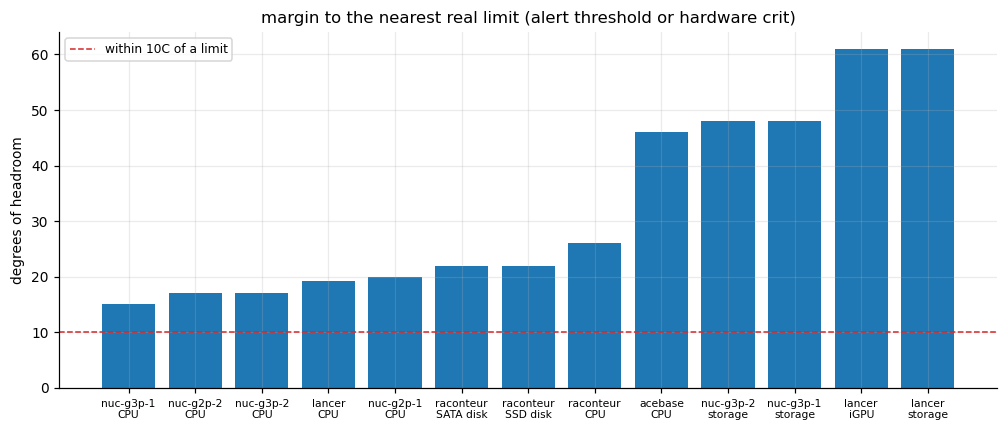

In [5]:
rows = []
for name, kind, cls, warn, _, _ in SENSORS:
    for dev, val in sorted(cur[name].items()):
        if dev in expected_devices and dev in stale:
            continue
        c = crit[name].get(dev)
        rows.append({
            'device': dev, 'class': cls, 'sensor': kind, 'now_C': val,
            'warn_C': warn, 'crit_C': c,
            'to_warn': (warn - val) if warn is not None else np.nan,
            'to_crit': (c - val) if c is not None else np.nan,
        })
fleet = pd.DataFrame(rows)
# Rank by whichever real limit is nearer; sensors with neither sort last and are the audit's job.
fleet['to_limit'] = fleet[['to_warn', 'to_crit']].min(axis=1)
fleet = fleet.sort_values('to_limit', na_position='last').reset_index(drop=True)

print(fleet.to_string(index=False, na_rep='-', float_format=lambda v: f'{v:.1f}'))
print(f"\nto_warn/to_crit = degrees below the mixin alert / the hardware's own crit."
      f"  to_limit = the nearer of the two (the real margin).")
if stale:
    print(f"UNASSESSABLE (stale, omitted above): {stale}")

fig, ax = plt.subplots(figsize=(11, 4.2))
sub = fleet.dropna(subset=['to_limit']).head(18)
lbl = [f"{r.device}\n{r.sensor}" for r in sub.itertuples()]
colors = ['C3' if r.to_limit < near_limit_margin_c else 'C0' for r in sub.itertuples()]
ax.bar(range(len(sub)), sub['to_limit'], color=colors)
ax.axhline(near_limit_margin_c, color='C3', ls='--', lw=1,
           label=f'within {near_limit_margin_c}C of a limit')
ax.set_xticks(range(len(sub)))
ax.set_xticklabels(lbl, fontsize=7)
ax.set_ylabel('degrees of headroom')
ax.set_title('margin to the nearest real limit (alert threshold or hardware crit)')
ax.legend(fontsize=8)
nbc.show(fig)

## Limit audit -- which sensors is anything actually watching?

The reason a fixed line and a hardware crit are both worth drawing. `node_hwmon_temp_crit_celsius`
is present on most but not all chips, and where a driver has no limit to report it emits a
sentinel (127 C here; the sibling `_max` metric reaches 65261.85 C on NVMe composite sensors)
rather than nothing. A sentinel read as a limit is worse than no limit at all -- a "93 C of
headroom" that does not exist.

`uncategorised` rows are sensors whose chip has no `node_hwmon_chip_names` entry, so no
chip_name join can reach them -- they are invisible to both the alerts and the Grafana board,
and only show up in an inventory like this one.

In [6]:
chipname = {(r['metric'].get('instance'), r['metric'].get('chip')): r['metric'].get('chip_name')
            for r in inv_chip}
critraw = {(r['metric'].get('instance'), r['metric'].get('chip'), r['metric'].get('sensor')):
           float(r['value'][1]) for r in inv_crit}

# Which chip_names a mixin alert or the dashboard actually selects on.
alerted_chips = set((metal_cpu_chips + '|' + metal_gpu_chips).split('|'))
charted_chips = alerted_chips | set(metal_storage_chips.split('|')) | {'coretemp'}

audit = []
for r in inv_temp:
    md_ = r['metric']
    dev, chip, sensor = md_.get('instance'), md_.get('chip'), md_.get('sensor')
    cn = chipname.get((dev, chip))
    craw = critraw.get((dev, chip, sensor))
    if craw is None:
        cstate, cval = 'none reported', np.nan
    elif crit_sane_min_c < craw < crit_sane_max_c:
        cstate, cval = 'usable', craw
    else:
        cstate, cval = f'SENTINEL ({craw:.0f})', np.nan
    audit.append({'device': dev, 'chip_name': cn or 'uncategorised', 'sensor': sensor,
                  'now_C': float(r['value'][1]), 'hw_crit': cstate, 'crit_C': cval,
                  'charted': (cn in charted_chips) if cn else False,
                  'alerted': (cn in alerted_chips) if cn else False})
aud = pd.DataFrame(audit).sort_values(['device', 'chip_name', 'sensor'])

def group_crit(states):
    """A chip is covered if ANY of its sensors reports a usable crit -- NVMe exposes the
    real limit only on the composite temp1, with temp2/temp3 silent, so a modal or
    all-sensors rule would call a protected drive unguarded."""
    states = list(states)
    if any(x == 'usable' for x in states):
        return 'usable'
    sentinels = [x for x in states if x.startswith('SENTINEL')]
    return sentinels[0] if sentinels else 'none reported'


summary = (aud.groupby(['device', 'chip_name'])
              .agg(sensors=('sensor', 'count'), hottest_C=('now_C', 'max'),
                   crit=('hw_crit', group_crit),
                   charted=('charted', 'first'), alerted=('alerted', 'first'))
              .reset_index())
print(summary.to_string(index=False, na_rep='-', float_format=lambda v: f'{v:.1f}'))

unguarded = summary[(~summary['alerted']) & (summary['crit'] != 'usable')]
print(f"\nsensor groups with NEITHER a mixin alert NOR a usable hardware crit: {len(unguarded)}")
for r in unguarded.itertuples():
    print(f"  {r.device:<12} {r.chip_name:<14} {r.sensors} sensor(s), hottest {r.hottest_C:.0f}C, crit: {r.crit}")
uncharted = summary[~summary['charted']]
print(f"\nsensor groups the Grafana board does not show: {len(uncharted)}")
for r in uncharted.itertuples():
    print(f"  {r.device:<12} {r.chip_name:<14} {r.sensors} sensor(s), hottest {r.hottest_C:.0f}C")

   device     chip_name  sensors  hottest_C           crit  charted  alerted
  acebase        acpitz        2       27.8  none reported    False    False
  acebase      coretemp        5       44.0         usable     True     True
  acebase     drivetemp        1       42.0 SENTINEL (127)     True    False
   lancer        acpitz        2       70.0  none reported    False    False
   lancer        amdgpu        1       34.0  none reported     True     True
   lancer       k10temp        1       70.8  none reported     True     True
   lancer          nvme        3       33.9         usable     True    False
nuc-g2p-1        acpitz        2       27.8  none reported    False    False
nuc-g2p-1      coretemp        5       70.0         usable     True     True
nuc-g2p-2        acpitz        2       27.8  none reported    False    False
nuc-g2p-2      coretemp        5       73.0         usable     True     True
nuc-g3p-1        acpitz        2       27.8  none reported    False    False

## 24h trend -- is anything moving, and where did it peak?

Now-versus-peak matters more than now alone: an instant reading taken between load spikes says
nothing about whether a box has been near its limit today.

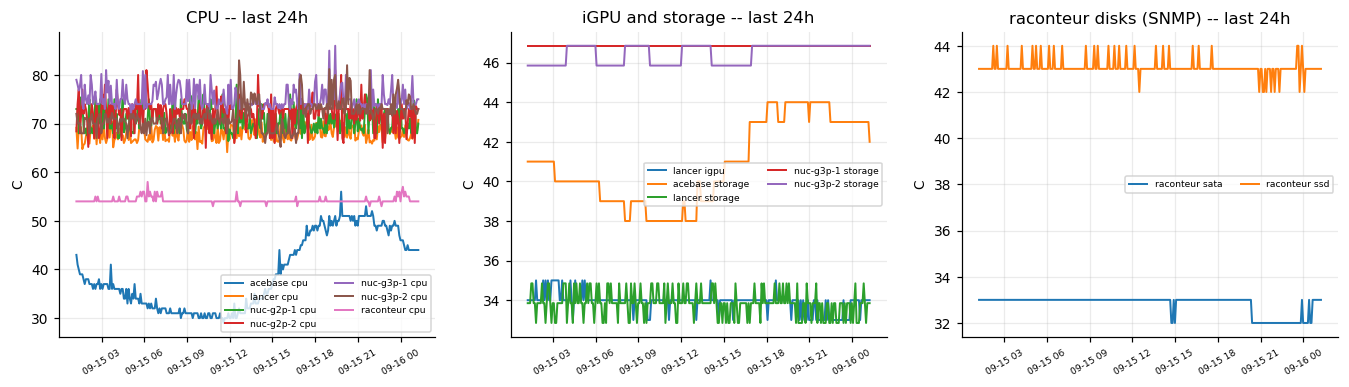

peak over the last 24h vs now (sorted by how close the PEAK came to the alert):
   device    sensor  now_C  peak_C     peak_at  warn_C  peak_to_warn
nuc-g3p-1       CPU   75.0    86.0 09-15 19:24    90.0           4.0
nuc-g3p-2       CPU   73.0    83.0 09-15 12:39    90.0           7.0
nuc-g2p-2       CPU   73.0    81.0 09-15 06:09    90.0           9.0
nuc-g2p-1       CPU   70.0    78.0 09-15 12:29    90.0          12.0
   lancer       CPU   70.8    70.9 09-15 13:49    90.0          19.1
raconteur  SSD disk   43.0    44.0 09-15 02:14    65.0          21.0
raconteur SATA disk   33.0    33.0 09-15 01:14    55.0          22.0
raconteur       CPU   54.0    58.0 09-15 06:14    80.0          22.0
  acebase       CPU   44.0    56.0 09-15 19:49    90.0          34.0
   lancer      iGPU   34.0    35.0 09-15 01:49    95.0          60.0
  acebase   storage   42.0    44.0 09-15 18:04       -             -
   lancer   storage   33.9    34.9 09-15 01:29       -             -
nuc-g3p-1   storage   4

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, (names, title) in zip(axes, [
    (['metal-cpu', 'proxmox-cpu', 'raconteur-cpu'], 'CPU'),
    (['metal-igpu', 'metal-storage', 'proxmox-storage'], 'iGPU and storage'),
    (['raconteur-sata', 'raconteur-ssd'], 'raconteur disks (SNMP)'),
]):
    for n in names:
        f = trend.get(n)
        if f is None or f.empty:
            continue
        for col in f.columns:
            ax.plot(f.index, f[col], lw=1.3, label=f'{col} {n.split("-", 1)[1]}')
    ax.set_title(f'{title} -- last {lookback_hours}h')
    ax.set_ylabel('C')
    ax.legend(fontsize=6, ncol=2)
    ax.tick_params(axis='x', labelsize=6, rotation=30)
nbc.show(fig)

peaks = []
for name, kind, cls, warn, _, _ in SENSORS:
    f = trend.get(name)
    if f is None or f.empty:
        continue
    for col in f.columns:
        s = f[col].dropna()
        if s.empty:
            continue
        peaks.append({'device': col, 'sensor': kind, 'now_C': cur[name].get(col, np.nan),
                      'peak_C': s.max(), 'peak_at': s.idxmax().strftime('%m-%d %H:%M'),
                      'warn_C': warn,
                      'peak_to_warn': (warn - s.max()) if warn is not None else np.nan})
pk = pd.DataFrame(peaks).sort_values('peak_to_warn', na_position='last')
print(f"peak over the last {lookback_hours}h vs now (sorted by how close the PEAK came to the alert):")
print(pk.to_string(index=False, na_rep='-', float_format=lambda v: f'{v:.1f}'))

## Throttle response -- is any of this heat costing performance?

Temperature only matters if something reacts to it. `node_cooling_device_cur_state` above zero
is the kernel actively throttling; the frequency ratio is a rougher proxy, and a deliberately
imperfect one -- it reads above 1.0 on hosts whose reported cpufreq max excludes turbo, so it
is only meaningful against a host's own history.

**Load belongs next to temperature, because to a first order it explains it.** A box that is
hot while working is doing its job; a box that is hot while idle, or whose temperature stops
tracking its load, has another heat source or a cooling problem. `temp~load_r` is that check as
one number per device -- and it is the reason the Grafana board carries CPU busy on the
right-hand axis of every temperature panel rather than in a separate row.

The correlation is only readable next to `load_p5_95`, how much the load actually moved. A host
whose load sat flat all day has nothing for its temperature to correlate with, and its r will be
near zero no matter how healthy it is -- so the weak-correlation finding requires real load
variation before it will say anything.

In [8]:
# Does load explain the heat? Correlate each device's CPU temperature against its host CPU
# busy over the window. High temperature with a high correlation is the workload doing its
# job; high temperature with a LOW correlation is the interesting case -- the heat has some
# other source, or the cooling has changed.
f_cputemp = pd.concat([trend[n] for n in ('metal-cpu', 'proxmox-cpu', 'raconteur-cpu')
                       if not trend[n].empty], axis=1)
temp_load_corr, load_spread = {}, {}
for d in present:
    if d in f_cputemp.columns and d in f_cpu.columns:
        joined = pd.concat([f_cputemp[d].rename('t'), f_cpu[d].rename('c')], axis=1).dropna()
        # A flat series has no correlation to measure; report NaN rather than a spurious 0.
        if len(joined) > 10 and joined['t'].std() > 0 and joined['c'].std() > 0:
            temp_load_corr[d] = joined['t'].corr(joined['c'])
            load_spread[d] = joined['c'].quantile(0.95) - joined['c'].quantile(0.05)

thr = pd.DataFrame([{
    'device': d,
    'hottest_C': max([v.get(d, np.nan) for v in cur.values() if d in v], default=np.nan),
    'cpu_busy%': cpu_busy.get(d),
    'temp~load_r': temp_load_corr.get(d), 'load_p5_95': load_spread.get(d),
    'throttle_step': cool_cur.get(d), 'throttle_frac': cool_frac.get(d),
    'freq_ratio': freq_ratio.get(d), 'power_W': power_w.get(d),
} for d in present]).sort_values('hottest_C', ascending=False)
print(thr.to_string(index=False, na_rep='-', float_format=lambda v: f'{v:.2f}'))
print("\ncpu_busy% = whole-host CPU now; temp~load_r = correlation of CPU temperature with host"
      f" CPU busy over {lookback_hours}h. Near 1 means load explains the heat; near 0 with a high"
      " temperature means something else does (airflow, ambient, a neighbour VM, failing fan)."
      f"\nRead temp~load_r ONLY against load_p5_95, the p5-p95 spread of that load: if the load"
      f" barely moved (< {min_load_spread_pct} points) there is nothing for the temperature to"
      " correlate WITH, and a near-zero r is an artifact of a flat series rather than evidence."
      "\nthrottle_step = highest passive cooling step in use now (0 = not throttling)."
      " throttle_frac = that step as a fraction of the device's own maximum, which is the only"
      " cross-host comparable form: Processor devices have 3 steps, raconteur's 10, and"
      " intel_powerclamp runs 0-100."
      "\nfreq_ratio = mean core freq / reported cpufreq max; >1.0 means the reported max excludes turbo.")

throttling = [d for d in present if (cool_cur.get(d) or 0) > 0]
print(f"\nactively throttling: {throttling or 'none'}")

   device  hottest_C  cpu_busy%  temp~load_r  load_p5_95  throttle_step  throttle_frac  freq_ratio  power_W
nuc-g3p-1      75.00      26.37         0.15        6.52           0.00           0.00        0.81        -
nuc-g2p-2      73.00      25.31         0.13        2.77           0.00           0.00        0.83        -
nuc-g3p-2      73.00      32.19         0.73       27.89           0.00           0.00        0.81        -
   lancer      70.75       3.95         0.12        0.33           0.00           0.00        0.49    26.06
nuc-g2p-1      70.00      21.63         0.08        4.80           0.00           0.00        0.82        -
raconteur      54.00       4.05         0.10        0.55           0.00           0.00        1.14        -
  acebase      44.00       5.92         0.02        0.19           0.00           0.00        0.49        -

cpu_busy% = whole-host CPU now; temp~load_r = correlation of CPU temperature with host CPU busy over 24h. Near 1 means load explains th

## Summary -- assumptions ledger, then findings against the sourced thresholds

In [9]:
findings = []
if stale:
    findings.append(f"UNASSESSABLE: {stale} stale/missing (> {metric_stale_s}s) -- box down or not scraping")
if not snmp_ok:
    findings.append(f"UNASSESSABLE: raconteur SNMP disk temps stale ({snmp_age:.0f}s) -- disk rows omitted")

# Alert-rule cross-check: zero firing is only "quiet" if the rules are loaded and healthy.
rule_state = {}
try:
    groups = rules_rec['json']['data']['groups']
    for grp in groups:
        if grp['name'].startswith('bond'):
            for rl in grp['rules']:
                rule_state[rl['name']] = (rl.get('state'), rl.get('health'))
except Exception as e:  # noqa: BLE001 -- a broken ruler API is itself the finding
    findings.append(f"could not read the ruler's loaded rules ({e}) -- 'no alerts firing' is unverified")
temp_rules = {k: v for k, v in rule_state.items() if 'Temperature' in k}
if not temp_rules:
    findings.append("no bond temperature alert rules loaded in the Mimir ruler -- nothing is watching")
unhealthy = {k: v for k, v in temp_rules.items() if v[1] != 'ok'}
if unhealthy:
    findings.append(f"bond temperature rules not healthy in the ruler: {unhealthy}")
if firing:
    for r in firing:
        findings.append(f"ALERT {r['metric'].get('alertname')} {r['metric'].get('alertstate')} "
                        f"on {r['metric'].get('instance', '?')}")

for r in fleet.itertuples():
    if not np.isnan(r.to_warn) and r.to_warn <= 0:
        findings.append(f"{r.device} {r.sensor}: {r.now_C:.0f}C at/over the {r.warn_C:.0f}C alert threshold")
    elif not np.isnan(r.to_warn) and r.to_warn < near_limit_margin_c:
        findings.append(f"{r.device} {r.sensor}: {r.now_C:.0f}C, only {r.to_warn:.0f}C below the "
                        f"{r.warn_C:.0f}C alert threshold")
    if not np.isnan(r.to_crit) and r.to_crit < near_limit_margin_c:
        findings.append(f"{r.device} {r.sensor}: {r.now_C:.0f}C, only {r.to_crit:.0f}C below the "
                        f"hardware crit of {r.crit_C:.0f}C")
for r in pk.itertuples():
    if not np.isnan(r.peak_to_warn) and r.peak_to_warn < near_limit_margin_c and (r.peak_C - r.now_C) > 5:
        findings.append(f"{r.device} {r.sensor}: peaked {r.peak_C:.0f}C at {r.peak_at} "
                        f"({r.peak_to_warn:.0f}C from the alert) though now {r.now_C:.0f}C")
for d in throttling:
    findings.append(f"{d}: passive thermal throttle active (cooling step {cool_cur[d]:.0f})")
# Heat the workload does not account for. Both rules are chosen, not sourced -- they point
# at a cooling problem rather than asserting one.
for r in thr.to_dict('records'):
    d, busy, corr = r['device'], r['cpu_busy%'], r['temp~load_r']
    near = fleet[(fleet['device'] == d) & (fleet['to_limit'] < near_limit_margin_c)]
    if len(near) and busy is not None and busy < idle_cpu_pct:
        findings.append(f"{d}: within {near_limit_margin_c}C of a limit while only {busy:.0f}% busy "
                        f"-- load does not explain this heat, suspect cooling")
    spread = r['load_p5_95']
    # Only meaningful when the load actually varied AND the box is near a limit. Without the
    # spread gate this fires on every host whose load is simply constant, which is not a
    # finding -- it is arithmetic.
    if (corr is not None and not np.isnan(corr) and corr < weak_corr
            and spread is not None and spread >= min_load_spread_pct and len(near)):
        findings.append(f"{d}: within {near_limit_margin_c}C of a limit, and its temperature tracks "
                        f"host load only weakly (r={corr:.2f} over {lookback_hours}h, load swung "
                        f"{spread:.0f} points) -- heat with another source")
if len(unguarded):
    hot = unguarded.sort_values('hottest_C', ascending=False)
    worst = ", ".join(f"{r.device}/{r.chip_name} {r.hottest_C:.0f}C" for r in hot.head(3).itertuples())
    findings.append(f"COVERAGE: {len(unguarded)} sensor group(s) have no mixin alert and no usable "
                    f"hardware crit -- nothing would catch them getting hot. Hottest: {worst}"
                    f"{' (full list in the limit audit above)' if len(unguarded) > 3 else ''}")

print("=== ASSUMPTIONS ===")
print(f"  mimir {mimir_age:.0f}s old | assessable {present} | unassessable {stale or 'none'}"
      f" | SNMP disks {'ok' if snmp_ok else 'STALE'}")
print(f"  bond temperature rules loaded in the ruler: {len(temp_rules)} "
      f"({sum(1 for v in temp_rules.values() if v[1] == 'ok')} healthy)")
print("\n=== FINDINGS ===")
for f_ in findings:
    print(f"  - {f_}")
if not findings:
    print("  none: every sensor is below every limit that applies to it, nothing is throttling,"
          " and every sensor has something watching it.")

=== ASSUMPTIONS ===
  mimir 1s old | assessable ['lancer', 'acebase', 'nuc-g2p-1', 'nuc-g2p-2', 'nuc-g3p-1', 'nuc-g3p-2', 'raconteur'] | unassessable none | SNMP disks ok
  bond temperature rules loaded in the ruler: 6 (6 healthy)

=== FINDINGS ===
  - nuc-g3p-1 CPU: peaked 86C at 09-15 19:24 (4C from the alert) though now 75C
  - nuc-g3p-2 CPU: peaked 83C at 09-15 12:39 (7C from the alert) though now 73C
  - nuc-g2p-2 CPU: peaked 81C at 09-15 06:09 (9C from the alert) though now 73C
  - COVERAGE: 7 sensor group(s) have no mixin alert and no usable hardware crit -- nothing would catch them getting hot. Hottest: lancer/acpitz 70C, acebase/drivetemp 42C, acebase/acpitz 28C (full list in the limit audit above)


In [10]:
# --- AGENT-READABLE STATS -- consolidated JSON, assumptions leading ---
def _n(v):
    return None if v is None or (isinstance(v, float) and not np.isfinite(v)) else round(float(v), 4)


agent_stats = {
    'notebook': f'{NOTEBOOK}.ipynb', 'run_at': cap.run_at, 'mode': cap.mode,
    'assumptions': {
        'status': 'ok' if (not stale and snmp_ok) else 'degraded',
        'mimir_age_s': _n(mimir_age),
        'device_age_s': {d: _n(dev_age[d]) for d in expected_devices},
        'assessable': present, 'unassessable': stale,
        'snmp_disk_feed_age_s': _n(snmp_age),
        'temperature_rules_loaded': {k: {'state': v[0], 'health': v[1]} for k, v in temp_rules.items()},
    },
    'findings': findings,
    'thresholds_chosen': {'idle_cpu_pct': idle_cpu_pct, 'weak_temp_load_corr': weak_corr,
                          'min_load_spread_pct': min_load_spread_pct},
    'thresholds_sourced': {
        'metal_cpu_c': metal_cpu_warn_c, 'metal_igpu_c': metal_gpu_warn_c,
        'proxmox_core_c': proxmox_core_warn_c, 'raconteur_cpu_c': raconteur_cpu_warn_c,
        'raconteur_sata_c': raconteur_sata_warn_c, 'raconteur_ssd_c': raconteur_ssd_warn_c,
        'crit_sane_band_c': [crit_sane_min_c, crit_sane_max_c],
        'near_limit_margin_c': near_limit_margin_c,
    },
    'sensors': [{
        'device': r['device'], 'class': r['class'], 'sensor': r['sensor'], 'now_c': _n(r['now_C']),
        'warn_c': _n(r['warn_C']), 'crit_c': _n(r['crit_C']), 'headroom_c': _n(r['to_limit']),
    } for r in fleet.to_dict('records')],
    'peaks_24h': [{'device': r.device, 'sensor': r.sensor, 'peak_c': _n(r.peak_C),
                   'peak_at': r.peak_at, 'now_c': _n(r.now_C)} for r in pk.itertuples()],
    'throttle': {d: {'throttle_step': _n(cool_cur.get(d)), 'throttle_frac': _n(cool_frac.get(d)),
                     'cpu_busy_pct': _n(cpu_busy.get(d)), 'temp_load_corr': _n(temp_load_corr.get(d)),
                     'load_spread_p5_95': _n(load_spread.get(d)),
                     'freq_ratio': _n(freq_ratio.get(d)), 'power_w': _n(power_w.get(d))}
                 for d in present},
    'raconteur_disks_c': {'sata': {k: _n(v) for k, v in disk_sata.items()},
                          'ssd': {k: _n(v) for k, v in disk_ssd.items()}},
    'coverage_gaps': [{'device': r.device, 'chip_name': r.chip_name, 'sensors': int(r.sensors),
                       'hottest_c': _n(r.hottest_C), 'hw_crit': r.crit}
                      for r in unguarded.itertuples()],
    'not_charted': [{'device': r.device, 'chip_name': r.chip_name, 'sensors': int(r.sensors)}
                    for r in uncharted.itertuples()],
}
print(json.dumps(agent_stats, indent=1))

if output_dir:
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)
    cap.save(out / f'{NOTEBOOK}-capture.json')
    (out / f'{NOTEBOOK}-stats.json').write_text(json.dumps(agent_stats, indent=1))
    print(f"\nwrote {out}/{NOTEBOOK}-capture.json and -stats.json")

{
 "notebook": "thermal-crossclass.ipynb",
 "run_at": "2026-09-16T01:14:11.630996+00:00",
 "mode": "live",
 "assumptions": {
  "status": "ok",
  "mimir_age_s": 1.22,
  "device_age_s": {
   "lancer": -0.0,
   "acebase": -0.0,
   "nuc-g2p-1": -0.0,
   "nuc-g2p-2": -0.0,
   "nuc-g3p-1": -0.0,
   "nuc-g3p-2": -0.0,
   "raconteur": -0.0
  },
  "assessable": [
   "lancer",
   "acebase",
   "nuc-g2p-1",
   "nuc-g2p-2",
   "nuc-g3p-1",
   "nuc-g3p-2",
   "raconteur"
  ],
  "unassessable": [],
  "snmp_disk_feed_age_s": -0.0,
  "temperature_rules_loaded": {
   "BondMetalHighCpuTemperature": {
    "state": "inactive",
    "health": "ok"
   },
   "BondMetalHighGpuTemperature": {
    "state": "inactive",
    "health": "ok"
   },
   "BondProxmoxHighCoreTemperature": {
    "state": "inactive",
    "health": "ok"
   },
   "BondRaconteurCpuTemperatureHigh": {
    "state": "inactive",
    "health": "ok"
   },
   "BondRaconteurSataDiskTemperatureHigh": {
    "state": "inactive",
    "health": "ok"
   },
